
# Stablecoins → Chains: an animated ranking‑race reel
### Your first end‑to‑end project with **gradient‑sankey** — built *com todo cuidado e carinho* 💚

Welcome! 👋 If this is your first time here, you're in exactly the right place.
This notebook is a **gentle, complete walk‑through** of a real project: we will scrape
**free DeFiLlama data** (no API key, no account), explore it, clean it, and turn it into the
**animated gradient‑Sankey ranking race** you may have seen on the reels — *where the stablecoin
supply actually lives across blockchains, month by month.*

By the end you'll have rendered your own frames of the same reel, and you'll understand every
moving part — including the small but clever bits (the **dynamic top‑N**, the **"Others" bucket**,
the **total‑market‑cap overlay**, and the **dynamic \$ axis**).

---

### What we'll build

A **ranking race**: the left column is the stablecoin **issuers** (USDT, USDC, DAI, …), the right
column is the **chains** they live on (Ethereum, Tron, Solana, …). Ribbons flow issuer → chain,
their width is the circulating supply, and **every frame is one month**. Issuers rise and fall,
a neutral **"Others"** bucket soaks up the long tail, and a footer chart tracks the **total
stablecoin market cap** like a bar‑chart race.

### Learning outcomes

1. Call the **free DeFiLlama stablecoin endpoints** and read their raw JSON.
2. Spot the real‑world **data quirks** (coins that didn't exist early, broken per‑chain history).
3. Build a tidy **long‑form DataFrame** `[tempo, origem, destino, valor]` — the only input the library needs.
4. Implement the **dynamic per‑period top‑N** and the **"Others = chain total − named"** bucket, and understand *why*.
5. Drive `gradient_sankey`: `from_dataframe → save_frame / animate`, with the race design (ranking + stacked, dark theme, glow, dynamic \$ axis, overlay).

> **This notebook is fully self‑contained.** It clones‑and‑runs from the gradient‑sankey repo: it
> imports only `gradient_sankey` (the committed module at the repo root), the Python standard library,
> and the pip packages `pandas` and `requests`. Every data fetch and every helper — the DeFiLlama
> calls, the dynamic top‑N, the "Others" bucket — is **inlined below as a teaching step**, so you can
> read the whole ETL pipeline end to end. 💚



## 1 · Setup & install

The library lives in this repo as a single module, `gradient_sankey.py`, at the **repo root**.
We add the repo root to `sys.path` so we always get the **local** copy with the newest features.

```bash
pip install gradient-sankey        # the public package
# this notebook uses the LOCAL repo copy via sys.path (see below)
```

> ⚠️ **Heads‑up — local‑only features (shipping in the next release).** This reel leans on a few
> capabilities that already exist in the **local** `gradient_sankey.py` but are **not yet in the
> published pip package**:
> - pinning a node named exactly **`"Others"`** to the bottom of the race,
> - **hiding zero‑value nodes** (so a coin can drop out of the top‑N and disappear cleanly),
> - the **layer‑total `$` value axis** (`yaxis_node`) plus **`yaxis_gap`** and **`layer0_label_side`**,
> - **decimal labels for sub‑\$1 values** (tiny early markets don't collapse to "0"),
> - the **gradient‑seam fix** (segments overlap, so no faint vertical lines).
>
> Importing the local module via `sys.path` (below) makes all of these work today. 🎁

We only need `requests` + `pandas` for the data, and the library for the visuals. Rendering an
**MP4** also needs **FFmpeg** on your PATH — but the still frames (`save_frame`) need nothing extra,
so the notebook stays runnable even without FFmpeg.


In [1]:
import os, sys, time, json

# --- import the LOCAL gradient_sankey from the repo root (committed module) ---
# This notebook lives in notebooks/, so the repo root is one level up.
REPO_ROOT = os.path.abspath("..")          # notebooks/  ->  repo root
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

import requests
import pandas as pd
import numpy as np
from IPython.display import Image, display

import gradient_sankey as gs
from gradient_sankey import SankeyRaceMultiLayerParallel as Sankey

# where we'll drop the rendered stills / sample clip (kept out of the repo root)
ASSETS = os.path.abspath("gallery_assets"); os.makedirs(ASSETS, exist_ok=True)
def show(path, w=900):
    return Image(filename=path, width=w)

print("gradient-sankey version:", gs.__version__)
print("pandas:", pd.__version__)


gradient-sankey version: 1.2.2
pandas: 3.0.1



## 2 · A 2‑minute DeFiLlama primer

[DeFiLlama](https://defillama.com/) publishes a **free, key‑less** stablecoins API. Four endpoints
are all we need (the exact ones the production adapter uses):

| Endpoint | What it gives you |
|---|---|
| `GET /stablecoins?includePrices=true` | the **list** of every stablecoin: `id`, `symbol`, current `circulating`, and a per‑chain breakdown |
| `GET /stablecoincharts/{chain}?stablecoin={id}` | **history** of one coin's circulating supply on **one chain** |
| `GET /stablecoincharts/all` | the **aggregate** circulating supply across *every* coin & chain (our overlay) |
| `GET /stablecoin/{id}` | full per‑coin detail (we won't need it today, but it's there) |

Base URL: `https://stablecoins.llama.fi`. No token, no sign‑up — just be polite (we pause briefly
between calls). Public APIs hiccup, so we wrap every GET in a tiny **retry helper** with exponential
backoff.


In [2]:
BASE = "https://stablecoins.llama.fi"

def get_json(url, params=None, tries=3, timeout=30, empty_default="raise"):
    """GET JSON with exponential backoff — public APIs hiccup, a tutorial shouldn't.

    DeFiLlama answers 200 with an EMPTY body for pairs that never existed
    (e.g. a coin that was never on a given chain). Pass empty_default=[] to get
    that back instead of an error.
    """
    last = None
    for i in range(tries):
        try:
            r = requests.get(url, params=params, timeout=timeout)
            r.raise_for_status()
            if not r.text.strip():
                if empty_default != "raise":
                    return empty_default
                raise ValueError("empty body")
            return r.json()
        except (requests.RequestException, ValueError) as e:
            last = e
            time.sleep(1.5 * (2 ** i))
    raise RuntimeError(f"Failed after {tries} tries on {url}: {last}")

print("helper ready ✔")

helper ready ✔



## 3 · Scraping the data

Three small fetches. We **cache** each response in a module‑level variable so re‑running cells is
instant and kind to the API.

### 3.1 · The stablecoin list

Every asset carries its current `circulating.peggedUSD` (USD supply) and a
`chainCirculating` breakdown. Let's pull it and peek at the raw JSON for the biggest coin.


In [3]:
# --- fetch the master list once, keep only coins with a real USD circulating ---
ASSETS_RAW = get_json(f"{BASE}/stablecoins?includePrices=true")["peggedAssets"]
ASSETS_RAW = [a for a in ASSETS_RAW if a.get("circulating", {}).get("peggedUSD")]
print(f"{len(ASSETS_RAW)} stablecoins with a USD circulating supply\n")

# peek at the raw shape for the largest coin (trimmed so the JSON is readable)
biggest = max(ASSETS_RAW, key=lambda a: a["circulating"]["peggedUSD"])
preview = {k: biggest[k] for k in ("id", "name", "symbol", "pegType", "circulating")}
preview["chainCirculating (first 3 chains)"] = dict(
    list(biggest.get("chainCirculating", {}).items())[:3]
)
print(json.dumps(preview, indent=2)[:1200])


303 stablecoins with a USD circulating supply

{
  "id": "1",
  "name": "Tether",
  "symbol": "USDT",
  "pegType": "peggedUSD",
  "circulating": {
    "peggedUSD": 186437310678.35025
  },
  "chainCirculating (first 3 chains)": {
    "Manta": {
      "current": {
        "peggedUSD": 2657894.9066077727
      },
      "circulatingPrevDay": {
        "peggedUSD": 2658166.2129196534
      },
      "circulatingPrevWeek": {
        "peggedUSD": 2658266.1345869694
      },
      "circulatingPrevMonth": {
        "peggedUSD": 2658880.4861776195
      }
    },
    "ThunderCore": {
      "current": {
        "peggedUSD": 299767.34900099033
      },
      "circulatingPrevDay": {
        "peggedUSD": 299767.34900099033
      },
      "circulatingPrevWeek": {
        "peggedUSD": 299767.34900099033
      },
      "circulatingPrevMonth": {
        "peggedUSD": 314442.6444364027
      }
    },
    "Movement": {
      "current": {
        "peggedUSD": 1847991.2709041063
      },
      "circulatingPrev


### 3.2 · Choosing the issuers and chains

There are two natural selection modes (we show the curated‑pool one, and note the other):

- a **curated symbol pool** (the reel's default) — issuers with *reliable* per‑chain history, e.g.
  `USDT, USDC, DAI, USDS, USD1, USDe, PYUSD, TUSD, FRAX`; or
- the **top‑N by current circulating** when no pool is given.

Then the chains are the **top‑`n_chains`** by the *aggregate* current supply of the chosen issuers —
computed by summing each coin's `chainCirculating[...].current.peggedUSD`.


In [4]:
# curated issuer pool (those with trustworthy per-chain history), like the reel's --symbols default
SYMBOL_POOL = ["USDT", "USDC", "DAI", "USDS", "USD1", "USDe", "PYUSD", "TUSD", "FRAX"]
N_CHAINS = 5

# resolve symbols -> asset records (first match per symbol wins, as in the adapter)
by_sym = {}
for a in ASSETS_RAW:
    by_sym.setdefault(a["symbol"], a)
stables = [by_sym[s] for s in SYMBOL_POOL if s in by_sym]
print("issuers:", [a["symbol"] for a in stables])

# top chains by AGGREGATE current supply of those issuers
chain_tot = {}
for a in stables:
    for ch, v in a.get("chainCirculating", {}).items():
        chain_tot[ch] = chain_tot.get(ch, 0) + v.get("current", {}).get("peggedUSD", 0)
CHAINS = [c for c, _ in sorted(chain_tot.items(), key=lambda kv: -kv[1])[:N_CHAINS]]
print("top chains:", CHAINS)
pd.Series(chain_tot).sort_values(ascending=False).head(8).apply(lambda x: f"${x/1e9:.1f}B")


issuers: ['USDT', 'USDC', 'DAI', 'USDS', 'USD1', 'USDe', 'PYUSD', 'TUSD', 'FRAX']
top chains: ['Ethereum', 'Tron', 'BSC', 'Solana', 'Hyperliquid L1']


Ethereum          $146.8B
Tron               $87.9B
BSC                $12.8B
Solana             $12.1B
Hyperliquid L1      $6.4B
Base                $4.6B
Arbitrum            $3.6B
Polygon             $3.3B
dtype: str


### 3.3 · Per‑(coin, chain) circulating history

For each issuer × chain we fetch the **history** endpoint and turn its `date`/`totalCirculating`
points into a time‑indexed pandas `Series` (USD → \$ **billions**). We pass `empty_default=[]` so a
pair that never existed (empty body) is simply skipped — not an error.

> 🪶 To keep this lesson **fast and light**, we sample only the last couple of years at
> **month‑ends** (the reel can go back to 2019). Same logic, smaller window.
>
> ⚠️ **These figures are live DeFiLlama data, anchored to `now()`** — your run will show current
> values, so they may differ from the outputs saved here.


In [5]:
MONTHS = 18          # small window so the notebook runs fast (the reel uses ~24-90)
PAUSE  = 0.15         # courtesy pause between requests

month_ends = pd.date_range(end=pd.Timestamp.now().normalize(),
                           periods=MONTHS, freq="ME").normalize()

# cache raw histories so re-running is instant
HIST_CACHE = {}
def chain_coin_history(chain, coin_id):
    key = (chain, coin_id)
    if key not in HIST_CACHE:
        HIST_CACHE[key] = get_json(f"{BASE}/stablecoincharts/{chain}",
                                   params={"stablecoin": coin_id}, empty_default=[])
        time.sleep(PAUSE)
    return HIST_CACHE[key]

rows = []
for a in stables:
    sym = a["symbol"]
    for ch in CHAINS:
        hist = chain_coin_history(ch, a["id"])
        if not hist:
            continue                       # this coin was never on this chain
        s = pd.Series({
            pd.to_datetime(int(p["date"]), unit="s"):
                p.get("totalCirculating", {}).get("peggedUSD", 0)
            for p in hist
        }).sort_index()
        for me in month_ends:
            upto = s.loc[:me]              # most recent value at/just before each month-end
            val = float(upto.iloc[-1]) / 1e9 if len(upto) else 0.0
            rows.append({"tempo": me.strftime("%Y-%m"), "origem": sym,
                         "destino": ch, "valor": max(val, 0.0)})

raw_long = pd.DataFrame(rows)
print(f"{len(raw_long)} raw (period, coin, chain) samples")
raw_long.head(8)


544 raw (period, coin, chain) samples


,tempo,origem,destino,valor
0,2025-01,USDT,Ethereum,65.903332
1,2025-02,USDT,Ethereum,66.213335
2,2025-03,USDT,Ethereum,65.008824
3,2025-04,USDT,Ethereum,64.815955
4,2025-05,USDT,Ethereum,62.392839
5,2025-06,USDT,Ethereum,63.468802
6,2025-07,USDT,Ethereum,67.038371
7,2025-08,USDT,Ethereum,73.192405



## 4 · Exploring the data — and its quirks

Real on‑chain data is messy in *interesting* ways. A quick look reveals the things our cleaning
step must respect:

- **Coins that didn't exist early.** USDe, USDS and USD1 are recent; their early months are simply
  **0** (or missing). The chart must let an issuer **appear** mid‑story rather than fake a value.
- **Broken / partial per‑chain history.** Some issuers (BUSD is the classic example) have an
  unreliable per‑chain breakdown — which is exactly why the reel works from a **curated pool** of
  issuers with trustworthy history, and folds everything else into **"Others"**.
- **Different scales.** USDT dwarfs the rest, so a fixed \$ axis would crush the small coins —
  motivating a **ranking race** (who's biggest *right now*) plus a scale that tracks the layer total.

Let's see who appears when, and how lopsided the supply is.


In [6]:
# how many chains each coin actually shows up on (non-zero), and when it first appears
appears = (raw_long[raw_long["valor"] > 0]
           .groupby("origem")
           .agg(first_month=("tempo", "min"),
                last_month=("tempo", "max"),
                chains=("destino", "nunique"))
           .reindex([a["symbol"] for a in stables]))
print("When each issuer first shows up in our window:")
display(appears)

# supply is extremely lopsided -> a ranking race is the right idiom
latest = raw_long["tempo"].max()
snap = (raw_long[raw_long["tempo"] == latest]
        .groupby("origem")["valor"].sum()
        .sort_values(ascending=False))
print(f"\nTotal circulating by issuer in {latest} (US$ B):")
display(snap.apply(lambda x: round(x, 2)))


When each issuer first shows up in our window:


,first_month,last_month,chains
origem,,,
USDT,2025-01,2026-05,5
USDC,2025-01,2026-05,5
DAI,2025-01,2026-05,3
USDS,2025-01,2026-05,2
USD1,2025-04,2026-05,4
USDe,2025-01,2026-05,4
PYUSD,2025-01,2026-05,3
TUSD,2025-01,2026-05,3
FRAX,2025-01,2026-05,3



Total circulating by issuer in 2026-05 (US$ B):


origem
USDT     182.09
USDC      64.12
USDS       8.38
USD1       4.72
DAI        3.75
USDe       3.64
PYUSD      2.70
TUSD       0.48
FRAX       0.18
Name: valor, dtype: float64


## 5 · Cleaning + the clever bits

This is the heart of the project. Three steps:

### 5.1 · A complete grid (every pair exists every period)

The animation wants a value for **every** (period, issuer, chain) — missing combos become **0** so
a node can smoothly shrink to nothing instead of blinking out. We build the full MultiIndex grid
and left‑merge our samples onto it. This long‑form table — columns
**`[tempo, origem, destino, valor]`** — is the *entire* contract with the library.


In [7]:
# full grid: every (period, issuer, chain) present; gaps -> 0.0
periods_all = sorted(raw_long["tempo"].unique())
grid = pd.MultiIndex.from_product(
    [periods_all, [a["symbol"] for a in stables], CHAINS],
    names=["tempo", "origem", "destino"]
).to_frame(index=False)

df = grid.merge(raw_long, how="left").fillna({"valor": 0.0})
print("tidy long-form df:", df.shape, "->", list(df.columns))
df.head()


tidy long-form df: (765, 4) -> ['tempo', 'origem', 'destino', 'valor']


,tempo,origem,destino,valor
0,2025-01,USDT,Ethereum,65.903332
1,2025-01,USDT,Tron,59.709665
2,2025-01,USDT,BSC,5.183215
3,2025-01,USDT,Solana,1.967925
4,2025-01,USDT,Hyperliquid L1,0.000000



### 5.2 · Dynamic top‑N **per period** — membership churns over time

A static "top 5 issuers" would be wrong: the leaderboard **changes** month to month. So for *each
period independently* we keep only the `n` largest issuers and **zero out the rest**. A coin that
slips out of the top‑N that month folds into "Others"; one that breaks back in reappears. The
library then **hides** the zeroed nodes.


In [8]:
def keep_top_n_per_period(df, n=5):
    """Per period, keep only the n largest issuers (by that period's total) and
    zero the rest, so top-N membership is DYNAMIC: a coin that falls out of the
    top-N folds into 'Others' that period, and one that rises breaks back out."""
    df = df.copy()
    coin_total = df.groupby(["tempo", "origem"])["valor"].sum()
    keep = set()
    for period, grp in coin_total.groupby(level="tempo"):
        for coin in grp.nlargest(n).index.get_level_values("origem"):
            keep.add((period, coin))
    drop = [(t, o) not in keep for t, o in zip(df["tempo"], df["origem"])]
    df.loc[drop, "valor"] = 0.0
    return df

TOP_N = 5
df = keep_top_n_per_period(df, TOP_N)

# show the churn: the kept issuer set for the first vs the last period
kept_by_period = (df[df["valor"] > 0].groupby("tempo")["origem"]
                  .apply(lambda s: sorted(set(s))))
print("Kept issuers, first period:", kept_by_period.iloc[0])
print("Kept issuers, last  period:", kept_by_period.iloc[-1])

Kept issuers, first period: ['DAI', 'USDC', 'USDS', 'USDT', 'USDe']
Kept issuers, last  period: ['DAI', 'USD1', 'USDC', 'USDS', 'USDT']



### 5.3 · The **"Others"** bucket = *chain total − named issuers*, pinned last

We only show a handful of issuers, but a chain carries **far more** than those. To keep the chart
**honest** — so each chain's ribbons sum to its *real* on‑chain total — we add a single **"Others"**
issuer. For each (period, chain) it is:

$$\text{Others} = \max\!\big(\text{chain total} - \textstyle\sum \text{named issuers},\ 0\big).$$

The **chain total** comes from `GET /stablecoincharts/{chain}` (no `stablecoin` param = *all* coins
on that chain). We name the node exactly **`"Others"`** because the library **pins that name to the
bottom** of the race, and colour it a neutral gray.


In [9]:
# chain-level totals (all coins) per chain, cached
CHAIN_TOTAL_CACHE = {}
def chain_total_series(chain):
    if chain not in CHAIN_TOTAL_CACHE:
        hist = get_json(f"{BASE}/stablecoincharts/{chain}", empty_default=[])
        CHAIN_TOTAL_CACHE[chain] = pd.Series({
            pd.to_datetime(int(p["date"]), unit="s"):
                (p.get("totalCirculating") or {}).get("peggedUSD", 0)
            for p in hist
        }).sort_index() / 1e9
        time.sleep(PAUSE)
    return CHAIN_TOTAL_CACHE[chain]

def add_others(df, chains):
    # Append an 'Others' issuer = chain total - named issuers, per (period, chain).
    # (the library pins a node named exactly 'Others' to the bottom of the race).
    periods = sorted(df["tempo"].unique())
    named = df.groupby(["tempo", "destino"])["valor"].sum()   # named total per (period, chain)
    rows = []
    for ch in chains:
        series = chain_total_series(ch)
        for per in periods:
            upto = series.loc[:pd.Timestamp(per) + pd.offsets.MonthEnd(0)]
            chain_total = float(upto.iloc[-1]) if len(upto) else 0.0
            others = max(chain_total - float(named.get((per, ch), 0.0)), 0.0)
            rows.append({"tempo": per, "origem": "Others", "destino": ch, "valor": others})
    return pd.concat([df, pd.DataFrame(rows)], ignore_index=True)

df = add_others(df, CHAINS)

# layers: issuers (+ Others) on the left, chains on the right
ISSUERS = [a["symbol"] for a in stables] + ["Others"]
LAYERS = [ISSUERS, CHAINS]
print("issuer layer:", ISSUERS)
print("chain  layer:", CHAINS)
df.tail()


issuer layer: ['USDT', 'USDC', 'DAI', 'USDS', 'USD1', 'USDe', 'PYUSD', 'TUSD', 'FRAX', 'Others']
chain  layer: ['Ethereum', 'Tron', 'BSC', 'Solana', 'Hyperliquid L1']


,tempo,origem,destino,valor
845,2026-01,Others,Hyperliquid L1,0.108657
846,2026-02,Others,Hyperliquid L1,0.100764
847,2026-03,Others,Hyperliquid L1,0.107837
848,2026-04,Others,Hyperliquid L1,0.178615
849,2026-05,Others,Hyperliquid L1,0.119468



### 5.4 · Node colours

Brand colours make the reel instantly readable. Any node we don't have a brand colour for falls back
to a pleasant accent; **"Others"** is a deliberate neutral gray so it never competes for attention.


In [10]:
STABLE_COLORS = {"USDT": "#26A17B", "USDC": "#2775CA", "DAI": "#F5AC37",
                 "USDS": "#84D58C", "USDE": "#8A92B2", "USD1": "#C9A86A"}
CHAIN_COLORS  = {"Ethereum": "#627EEA", "Tron": "#FF4B4B", "Solana": "#9945FF",
                 "BSC": "#F0B90B", "Base": "#0052FF", "Arbitrum": "#28A0F0",
                 "Polygon": "#8247E5", "Avalanche": "#E84142",
                 "Hyperliquid L1": "#50E3C2", "OP Mainnet": "#FF0420"}
FALLBACK = ["#4CC9F0", "#F72585", "#B5179E", "#7209B7", "#4361EE",
            "#4895EF", "#52B788", "#FFB703"]

node_colors, i = {}, 0
for n in [a["symbol"] for a in stables] + CHAINS:
    node_colors[n] = (STABLE_COLORS.get(n.upper()) or STABLE_COLORS.get(n)
                      or CHAIN_COLORS.get(n) or FALLBACK[i % len(FALLBACK)])
    i += 1
node_colors["Others"] = "#6B7280"   # neutral gray, pinned last by the library
node_colors


{'USDT': '#26A17B',
 'USDC': '#2775CA',
 'DAI': '#F5AC37',
 'USDS': '#84D58C',
 'USD1': '#C9A86A',
 'USDe': '#8A92B2',
 'PYUSD': '#52B788',
 'TUSD': '#FFB703',
 'FRAX': '#4CC9F0',
 'Ethereum': '#627EEA',
 'Tron': '#FF4B4B',
 'BSC': '#F0B90B',
 'Solana': '#9945FF',
 'Hyperliquid L1': '#50E3C2',
 'Others': '#6B7280'}


## 6 · The total‑market‑cap overlay

The footer of the reel is a **bar‑chart‑race** style chart of the **total stablecoin market cap** —
across *every* coin and chain — sampled at each of our period‑ends. It comes from the aggregate
`/stablecoincharts/all` endpoint, summing `totalCirculatingUSD` (→ \$ billions).


In [11]:
def total_mcap_series(periods):
    # Total stablecoin market cap (US$ B) at each period-end, from the aggregate
    # /stablecoincharts/all endpoint (every stablecoin and chain).
    chart = get_json(f"{BASE}/stablecoincharts/all")
    series = pd.Series({
        pd.to_datetime(int(p["date"]), unit="s"):
            sum((p.get("totalCirculatingUSD") or {}).values())
        for p in chart
    }).sort_index() / 1e9
    out = []
    for per in periods:
        month_end = pd.Timestamp(per) + pd.offsets.MonthEnd(0)
        upto = series.loc[:month_end]
        out.append(float(upto.iloc[-1]) if len(upto) else float("nan"))
    return out

periods = sorted(df["tempo"].unique())
overlay = total_mcap_series(periods)
# year-first quarter ticks for the overlay's x-axis, like the reel
xlabels = [f"{p[:4]} Q{(int(p[5:7]) - 1) // 3 + 1}" for p in periods]
print(f"total stablecoin mcap: ${overlay[0]:.0f}B  ->  ${overlay[-1]:.0f}B over {len(periods)} months")


total stablecoin mcap: $219B  ->  $320B over 17 months



## 7 · Building the visual — every knob explained

Now the fun part. The library takes our tidy `df` + `layers` and we hand `animate()` (or
`save_frame()`) a set of design knobs. Here's what each one does in **this** reel:

| Knob | Value | Why |
|---|---|---|
| `ranking_mode` | `True` | reorder issuers by value each frame — *the race* |
| `stacked_mode` | `True` | bar heights scale with supply (biggest = tallest) |
| `theme` | `"dark"` | the neon‑on‑black reel look |
| `link_glow` / `link_alpha` | `1` / `0.55` | soft neon glow behind the ribbons |
| `n_segments` | `100` | smooth gradients (the seam fix makes 100 look like 200) |
| `yaxis_node` | an issuer | draw a **\$ axis** scaled to the issuer‑layer **total** |
| `yaxis_suffix` | `"B"` | ticks read like `$50B` |
| `yaxis_gap` | `0.15` | nudge the axis to hug the issuer column |
| `layer0_label_side` | `"right"` | issuer names sit to the **right**, clearing the left‑side axis |
| `overlay_series` / `overlay_x_labels` | total mcap / quarter ticks | the footer race chart |
| `overlay_label/color/value_suffix/badge` | … | footer styling + the `TOTAL` badge |

First, build the renderer from the DataFrame — the single call that ingests everything.


In [12]:
sk = Sankey.from_dataframe(
    df=df, layers=LAYERS,
    time_col="tempo", source_col="origem", target_col="destino", value_col="valor",
    node_colors=node_colors,
)
anchor = LAYERS[0][0]   # any issuer identifies the layer for the $ axis
print(f"{len(sk.frames)} frames (months):", sk.frames[0]['time_label'], "->", sk.frames[-1]['time_label'])
print("$ axis anchored on layer of:", anchor)


17 frames (months): 2025-01 -> 2026-05
$ axis anchored on layer of: USDT



## 8 · Render a short proof

Stills first — `save_frame()` needs **no FFmpeg**, so this always works. We render the **first** and
**last** month so you can see the race's start and finish, with the full reel design applied.


Frame saved to: C:\Users\Felipe\Downloads\python_projects\math_projects\animated_sankey_plot\notebooks\gallery_assets\stables_first.png


Frame saved to: C:\Users\Felipe\Downloads\python_projects\math_projects\animated_sankey_plot\notebooks\gallery_assets\stables_last.png


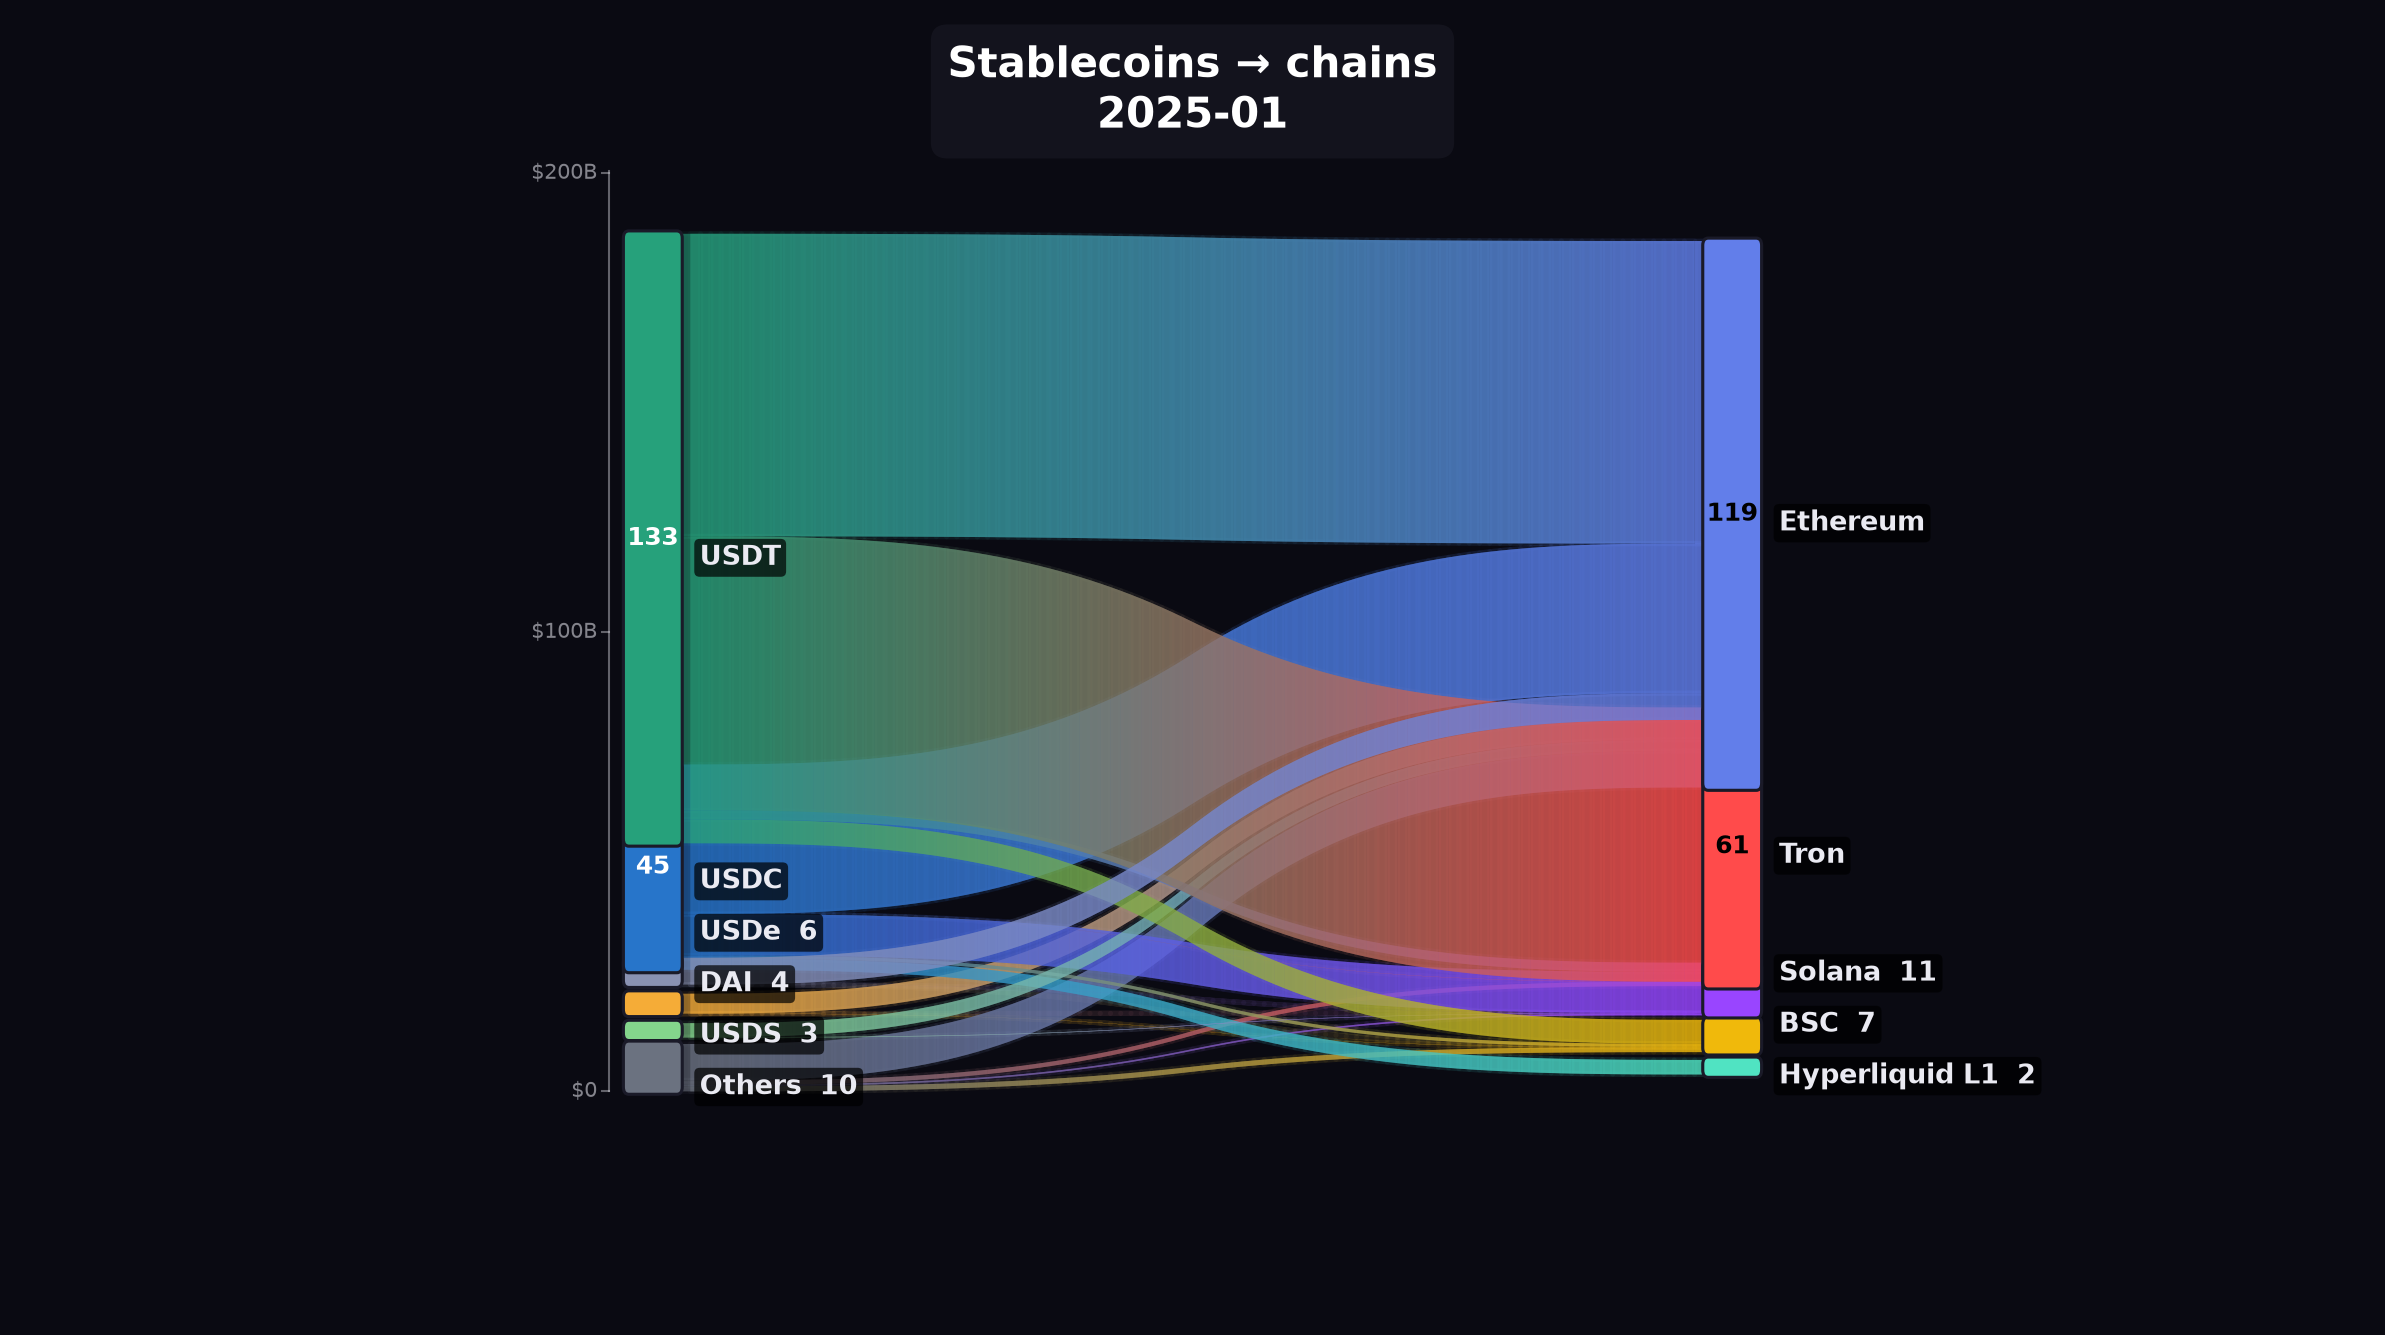

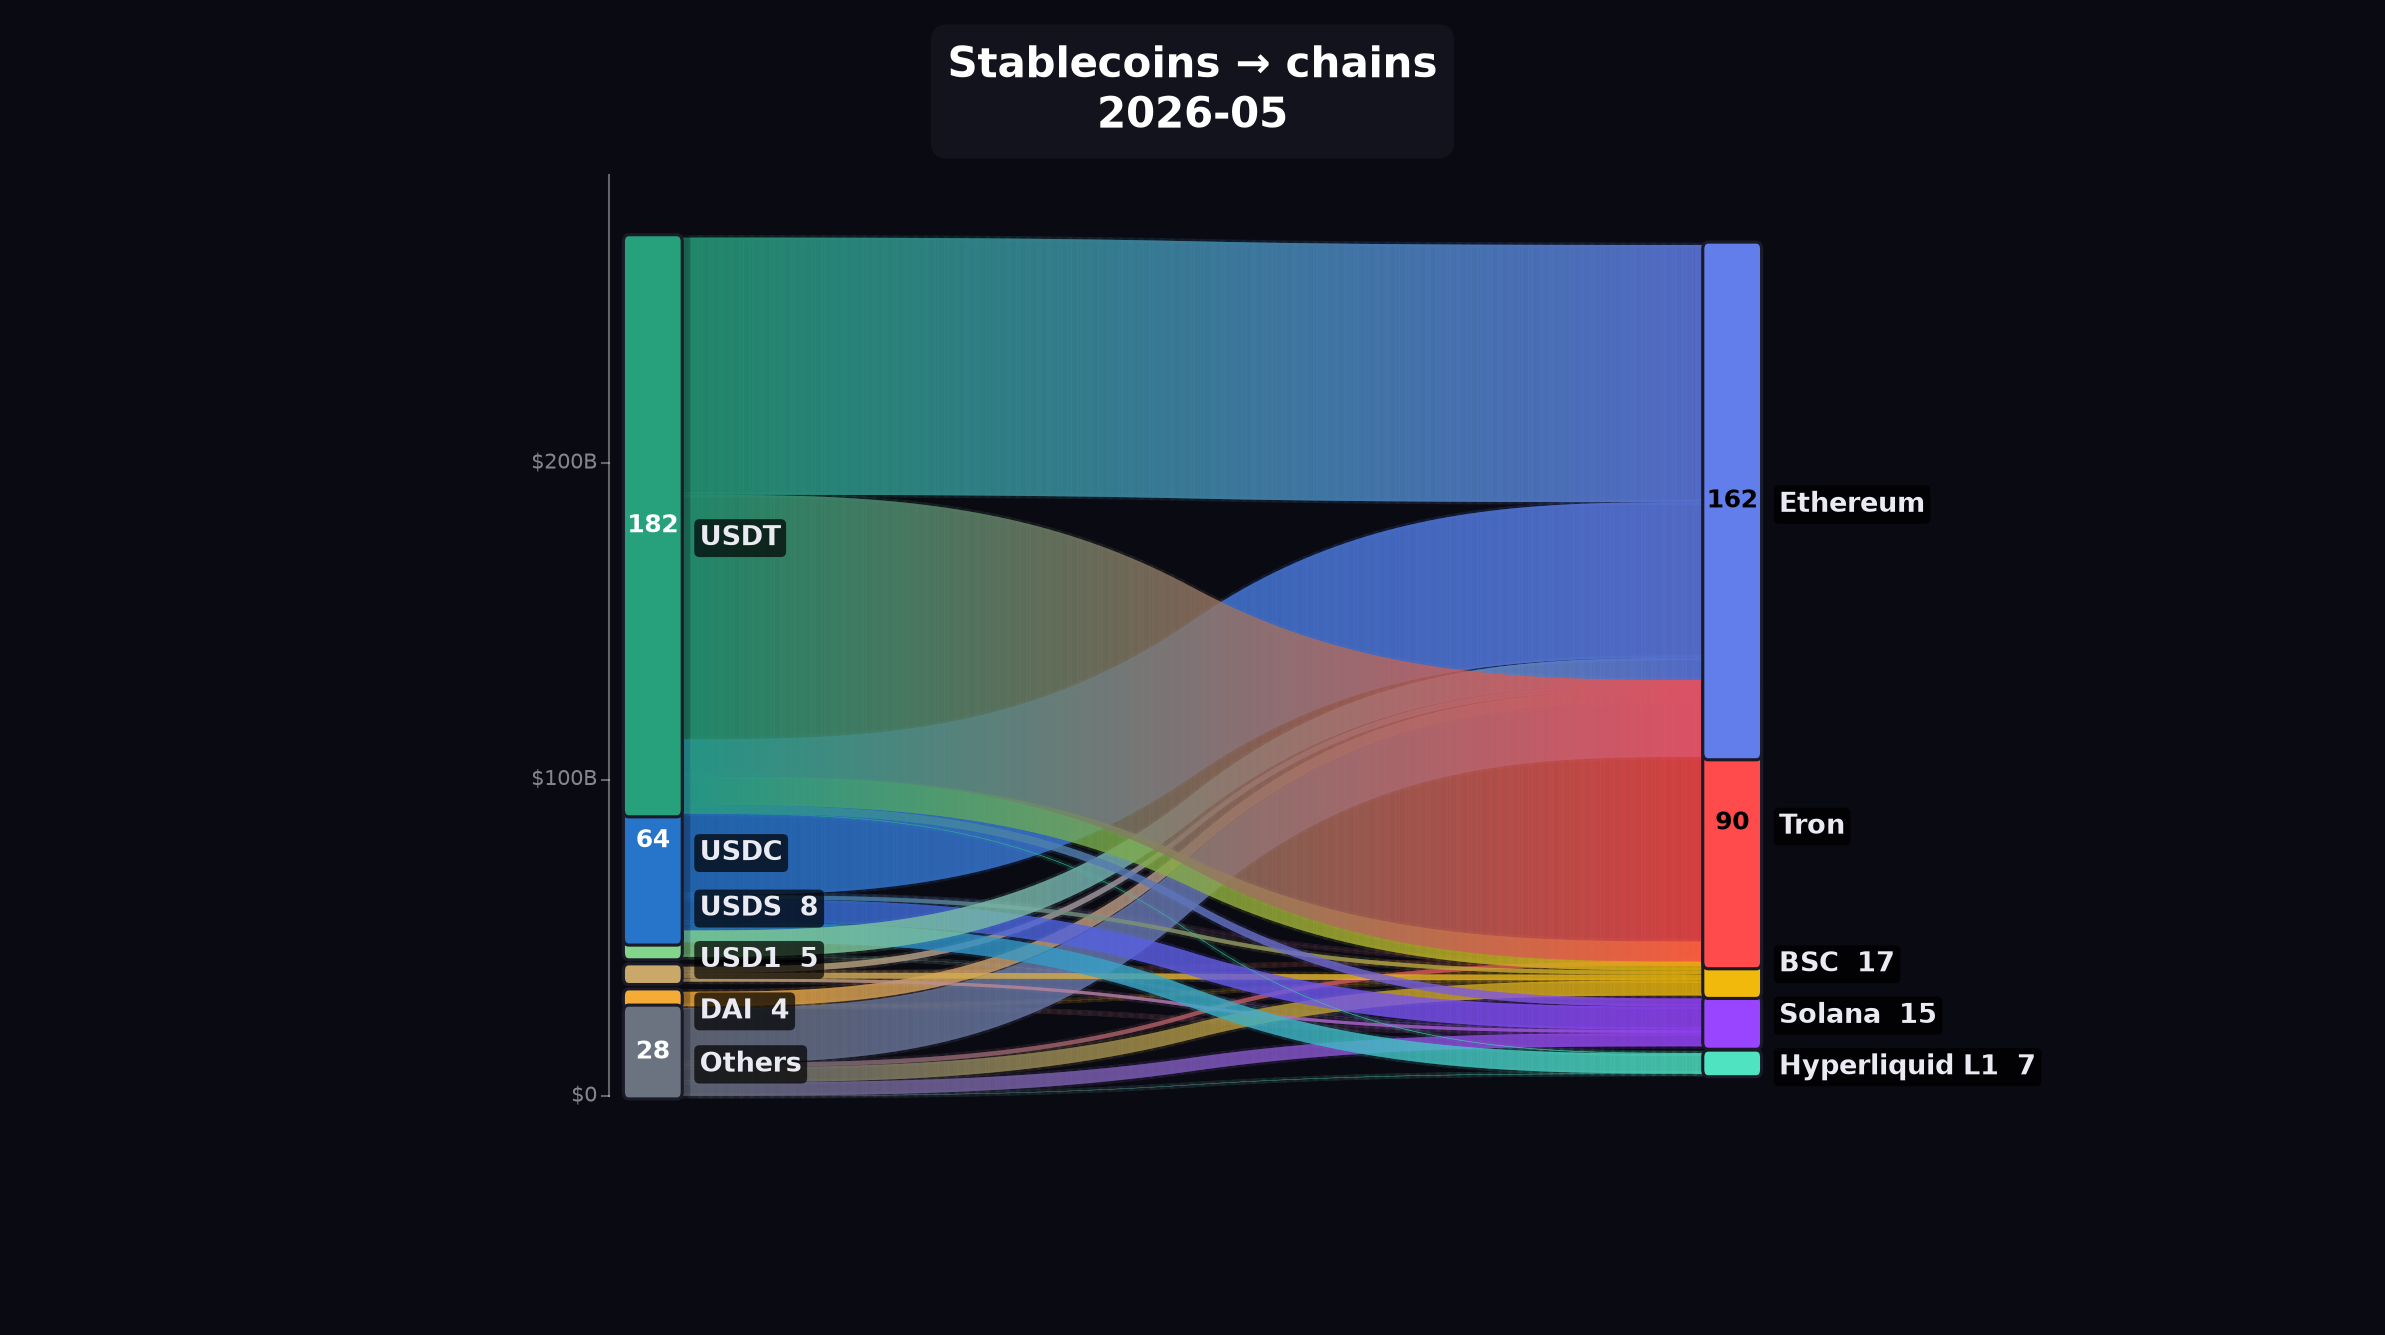

In [13]:
design = dict(
    figsize=(16, 9), font_size=13, title_fontsize=20, padding=2.8,
    margin_top=0.16, margin_bottom=0.20,
    ranking_mode=True, stacked_mode=True,        # the race: reorder AND resize
    theme="dark", link_glow=1, link_alpha=0.55,
    n_segments=100,
    yaxis_node=anchor, yaxis_suffix="B",         # dynamic $ axis (scaled to the layer TOTAL)
    yaxis_gap=0.15, layer0_label_side="right",   # axis hugs the issuers; names on the right
)

first_png = os.path.join(ASSETS, "stables_first.png")
last_png  = os.path.join(ASSETS, "stables_last.png")
sk.save_frame(first_png, frame_index=0,
              title="Stablecoins → chains", **design)   # the library adds the period as a subtitle
sk.save_frame(last_png, frame_index=len(sk.frames) - 1,
              title="Stablecoins → chains", **design)
display(show(first_png, w=1000))
display(show(last_png, w=1000))



### One short animation (optional — needs FFmpeg)

Now a tiny clip to prove the motion. The overlay is **animation‑only**, so it shows up here. We keep
it short (a few seconds) for speed; the cell **skips gracefully** if FFmpeg isn't installed.


In [14]:
sample_mp4 = os.path.join(ASSETS, "stables_sample.mp4")
try:
    sk.animate(
        sample_mp4,
        fps=24, duration_seconds=6, quality="medium", n_workers=2,
        title="Stablecoins → chains — where the supply lives",
        overlay_series=overlay, overlay_x_labels=xlabels,
        overlay_label="Total stablecoin market cap  (US$ B)",
        overlay_color="#7CFF6B", overlay_value_suffix="B", overlay_badge="TOTAL",
        **design,
    )
    from IPython.display import Video
    print("rendered:", sample_mp4)
    display(Video(sample_mp4, embed=True, width=900))
except Exception as e:
    print("Skipping the MP4 (FFmpeg likely not installed) — the stills above tell the story.")
    print("Reason:", repr(e))


Settings (MULTI-LAYER PARALLEL):
  - Layers: 2
  - Nodes per layer: [10, 5]
  - FPS: 24, Duration: 6s
  - Quality: medium
  - Total frames: 144
  - Gradient segments: 100
  - Positioning mode: Stacked + Ranking
  - Dynamic color mode: Static

Pre-computing 144 frames...


  Pre-computation: 4.84s
  Workers: 2

Rendering on 2 parallel processes...


  Parallel rendering: 210.34s (0.7 fps)

Concatenating 2 chunks...


  Concatenation: 1.50s

Animation saved to: C:\Users\Felipe\Downloads\python_projects\math_projects\animated_sankey_plot\notebooks\gallery_assets\stables_sample.mp4
Total time: 211.85s (0.7 effective fps)
rendered: C:\Users\Felipe\Downloads\python_projects\math_projects\animated_sankey_plot\notebooks\gallery_assets\stables_sample.mp4



### The full 50‑second reel — one line

To render the **whole** reel at full length, widen the window (bump `MONTHS` near the top — the reel
goes back to 2019) and hand `animate()` a longer duration. Everything you need is already in this
notebook:

```python
# reproduce this notebook's pipeline at full length:
from gradient_sankey import SankeyRaceMultiLayerParallel as Sankey
sk.animate("stablecoins.mp4", fps=30, duration_seconds=50, quality="high", n_workers=4,
           overlay_series=overlay, overlay_x_labels=xlabels,
           overlay_label="Total stablecoin market cap  (US$ B)",
           overlay_color="#7CFF6B", overlay_value_suffix="B", overlay_badge="TOTAL",
           **design)
```

> 🗂️ A nice habit for the output filename: stamp it with a **big‑endian, sortable** date‑time prefix
> (`%Y-%m-%d-%Hh%M`, with `:` → `h` because it's illegal in paths) — so your renders always sort
> chronologically.



## 9 · Recap & try it yourself

🎉 **You built the whole reel** — from raw DeFiLlama JSON to an animated gradient Sankey ranking race.

**The pipeline, in one breath:** fetch the coin list → pick issuers & top chains → pull per‑(coin,
chain) history → build the complete long‑form grid → **dynamic per‑period top‑N** → **"Others" =
chain total − named** (pinned last) → total‑mcap overlay → `from_dataframe` → `save_frame` /
`animate` with the race design.

### 🧪 Try it yourself

1. **More history.** Bump `MONTHS` to 36+ (or set the reel's `--since 2019`) and watch BUSD's rise
   and fall, and USDe/USDS appear.
2. **Different top‑N.** Set `TOP_N = 3` or `7` and re‑run from §5.2 — see membership churn more/less.
3. **More chains.** Raise `N_CHAINS` to 6–8 and watch the L2s (Base, Arbitrum) enter the right column.
4. **Skip "Others".** Comment out the `add_others` call to see only the named issuers (less honest,
   but a useful contrast).
5. **Your own data.** The library only needs a tidy `[tempo, origem, destino, valor]` frame + `layers`.
   Point it at *anything* that flows.

### 🔗 Links

- The library: `gradient_sankey.py` (repo root) · `pip install gradient-sankey`
- DeFiLlama stablecoins API (free, no key): https://stablecoins.llama.fi/stablecoins
- Companion tutorials: `notebooks/03_tutorial_energy.ipynb` (another live‑API source → chain race)
  and `notebooks/11_tutorial_alphabet.ipynb` (the flagship company‑financials format)

> 💡 Remember: pinning **"Others"**, hiding zero nodes, the layer‑total **\$ axis**, `yaxis_gap`,
> `layer0_label_side`, sub‑\$1 decimal labels and the gradient‑seam fix are **local‑only** today —
> they ship in the **next release**. Until then, import the local module via `sys.path` (as we did
> in §1) and everything just works. 💚

*Built com todo cuidado e carinho. Data: DeFiLlama (free, no API key). Happy hacking!*
